# Customer Churn Prediction — Stage 4: SHAP Explainability + Revenue Impact

Goal: Answer not just *who* will churn, but *why* — and translate that into
exact dollar figures the business can act on.

**Why SHAP?**
SHAP (SHapley Additive exPlanations) is grounded in game theory. It assigns
each feature a contribution score for every individual prediction — not just
a global importance rank. This means we can explain to a customer why they
were flagged, and to a manager exactly which levers to pull.

**Interview talking point:** Most churn notebooks stop at "model accuracy."
Adding SHAP explainability + revenue quantification is what makes this
production-grade and business-relevant.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pickle
import shap
import sqlite3
import warnings
import os

from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
shap.initjs()

os.makedirs('../outputs', exist_ok=True)

sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'savefig.dpi'      : 150,
    'savefig.bbox'     : 'tight'
})

print("Libraries loaded.")

Libraries loaded.


## 1. Load Model and Data

In [2]:
# Load trained XGBoost model
with open('../outputs/churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load feature dataset
df = pd.read_csv('../data/telco_features.csv')

print(f"Model loaded  : {type(model).__name__}")
print(f"Data loaded   : {df.shape[0]:,} rows × {df.shape[1]} columns")

# Recreate the exact same X, y, and train/test split used in Stage 3
drop_cols = [c for c in ['customerID', 'Churn', 'Churn_Binary'] if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42   # MUST match Stage 3
)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print("✅ Train/test split matches Stage 3 exactly.")

Model loaded  : XGBClassifier
Data loaded   : 7,043 rows × 57 columns

X_train : (5634, 54)
X_test  : (1409, 54)
✅ Train/test split matches Stage 3 exactly.


## 2. Create SHAP Explainer and Calculate SHAP Values

`TreeExplainer` is optimised for tree-based models (XGBoost, LightGBM, RandomForest).
It is orders of magnitude faster than the model-agnostic `KernelExplainer`.

SHAP values tell us: *"How much did this feature push the prediction
above or below the average prediction?"*
- Positive SHAP value → pushed prediction toward churn
- Negative SHAP value → pushed prediction away from churn

In [3]:
print("Creating TreeExplainer and computing SHAP values...")
print("(This may take 1-2 minutes for the full test set)\n")

explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Clean up feature names for display (replace underscores with spaces)
readable_names = [name.replace('_', ' ') for name in X_test.columns]

# Create a copy of shap_values with readable feature names for plots
X_test_display           = X_test.copy()
X_test_display.columns   = readable_names
shap_values_display      = explainer(X_test_display)

print(f"SHAP values computed for {len(X_test):,} test customers.")
print(f"Shape of SHAP values matrix: {shap_values.values.shape}")
print(f"  → {shap_values.values.shape[0]} customers × {shap_values.values.shape[1]} features")

Creating TreeExplainer and computing SHAP values...
(This may take 1-2 minutes for the full test set)

SHAP values computed for 1,409 test customers.
Shape of SHAP values matrix: (1409, 54)
  → 1409 customers × 54 features


## 3. Plot 1 — Global SHAP Beeswarm Summary

Each dot = one customer. Position on x-axis = SHAP value (impact on prediction).
Color = actual feature value (red = high, blue = low).

**How to read this:** If Contract Month-to-month has many red dots on the right,
it means high values of that feature (i.e., being on month-to-month) strongly
pushes predictions toward churn.

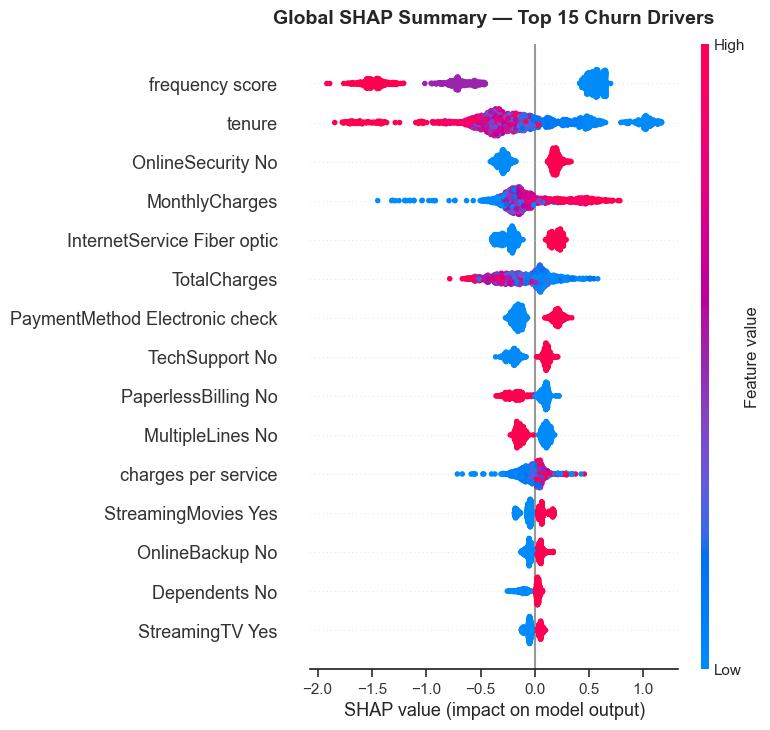

Saved → outputs/shap_summary.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_values_display,
    X_test_display,
    plot_type='dot',
    max_display=15,
    show=False
)

plt.title('Global SHAP Summary — Top 15 Churn Drivers',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png')
plt.show()
print("Saved → outputs/shap_summary.png")

## 4. Plot 2 — SHAP Bar Chart (Mean Absolute Values)

The bar chart shows overall feature importance — averaged across all customers.
This is easier to communicate to non-technical stakeholders than the beeswarm.

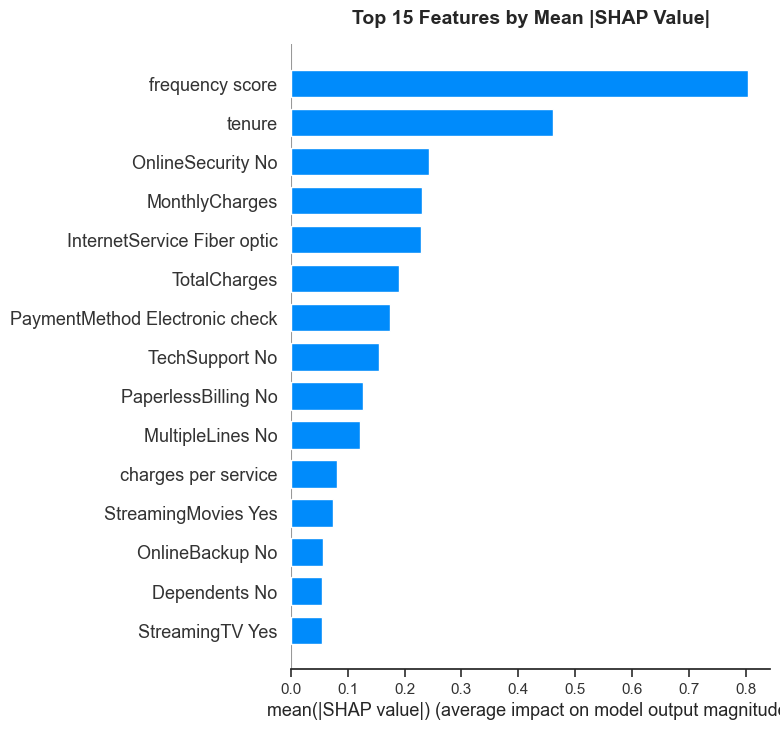

Saved → outputs/shap_bar.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    shap_values_display,
    X_test_display,
    plot_type='bar',
    max_display=15,
    show=False
)

plt.title('Top 15 Features by Mean |SHAP Value|',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png')
plt.show()
print("Saved → outputs/shap_bar.png")

## 5. Select 3 Representative Customers for Waterfall Plots

We pick:
- **High risk**: the customer our model is most confident will churn
- **Borderline**: a customer right on the fence (~50th percentile)
- **Safe**: the customer our model is most confident will NOT churn

Waterfall plots show exactly which features drove each individual prediction.
This is the feature that makes this project stand out — individual-level explainability.

In [6]:
# Get predicted churn probabilities for test set
y_prob_test = model.predict_proba(X_test)[:, 1]

prob_series = pd.Series(y_prob_test, index=X_test.index, name='churn_prob')

# Highest probability — most likely to churn
idx_high = prob_series.idxmax()
pos_high = prob_series.index.get_loc(idx_high)

# Lowest probability — safest customer
idx_low  = prob_series.idxmin()
pos_low  = prob_series.index.get_loc(idx_low)

# ~50th percentile — borderline customer
median_prob = prob_series.median()
idx_mid  = (prob_series - median_prob).abs().idxmin()
pos_mid  = prob_series.index.get_loc(idx_mid)

print("=== SELECTED CUSTOMERS ===\n")
print(f"HIGH RISK   → index {idx_high} | churn prob = {prob_series[idx_high]:.4f} ({prob_series[idx_high]*100:.1f}%)")
print(f"BORDERLINE  → index {idx_mid}  | churn prob = {prob_series[idx_mid]:.4f} ({prob_series[idx_mid]*100:.1f}%)")
print(f"SAFE        → index {idx_low}  | churn prob = {prob_series[idx_low]:.4f} ({prob_series[idx_low]*100:.1f}%)")

=== SELECTED CUSTOMERS ===

HIGH RISK   → index 4585 | churn prob = 0.9699 (97.0%)
BORDERLINE  → index 1520  | churn prob = 0.3533 (35.3%)
SAFE        → index 1815  | churn prob = 0.0032 (0.3%)


## 6. Waterfall Plots — Individual Customer Explanations

A waterfall plot starts from the base value (average model output across all customers)
and shows how each feature pushes the prediction up (red) or down (blue) to reach
the final predicted probability for this specific customer.

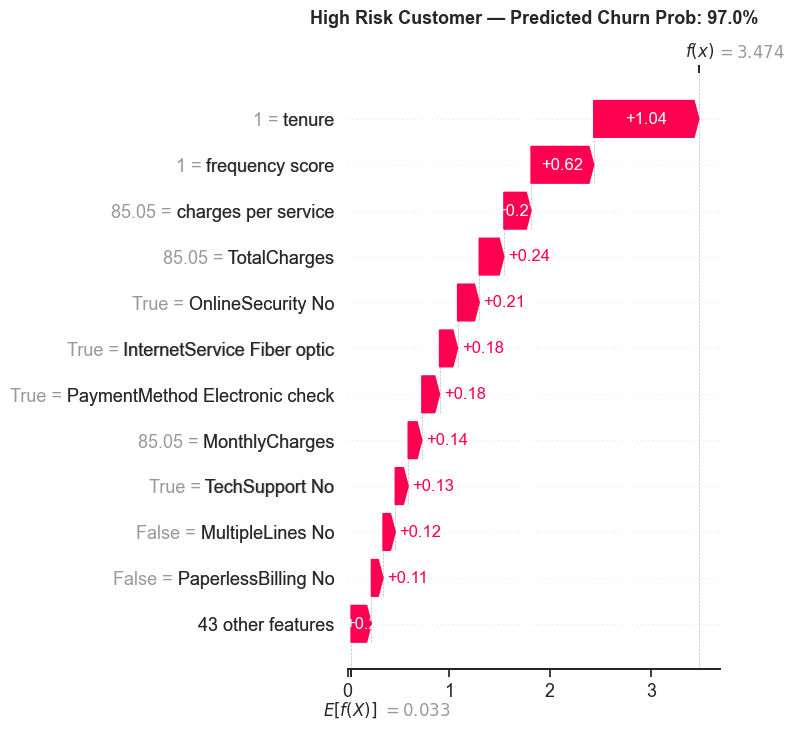

Saved → outputs/shap_waterfall_high.png


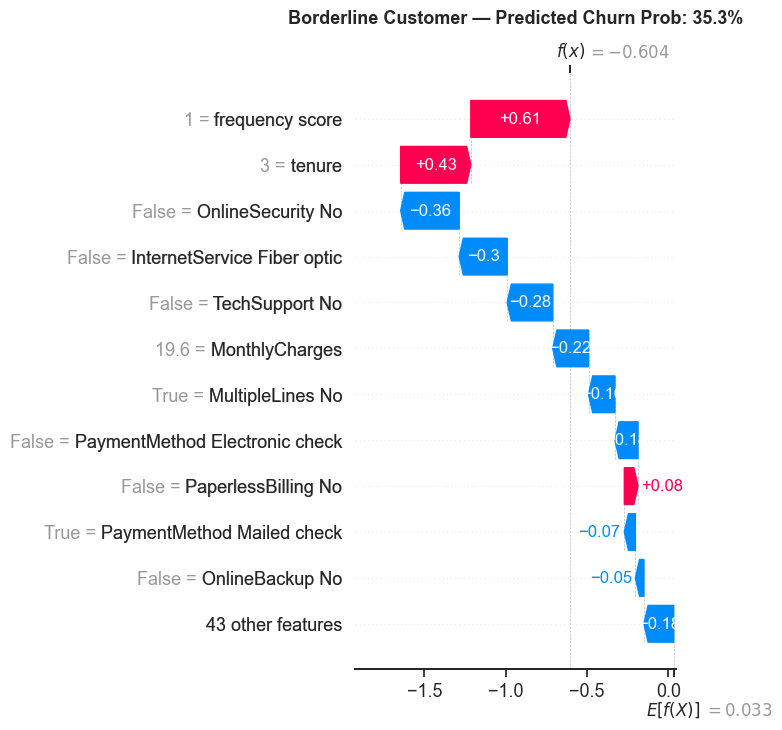

Saved → outputs/shap_waterfall_mid.png


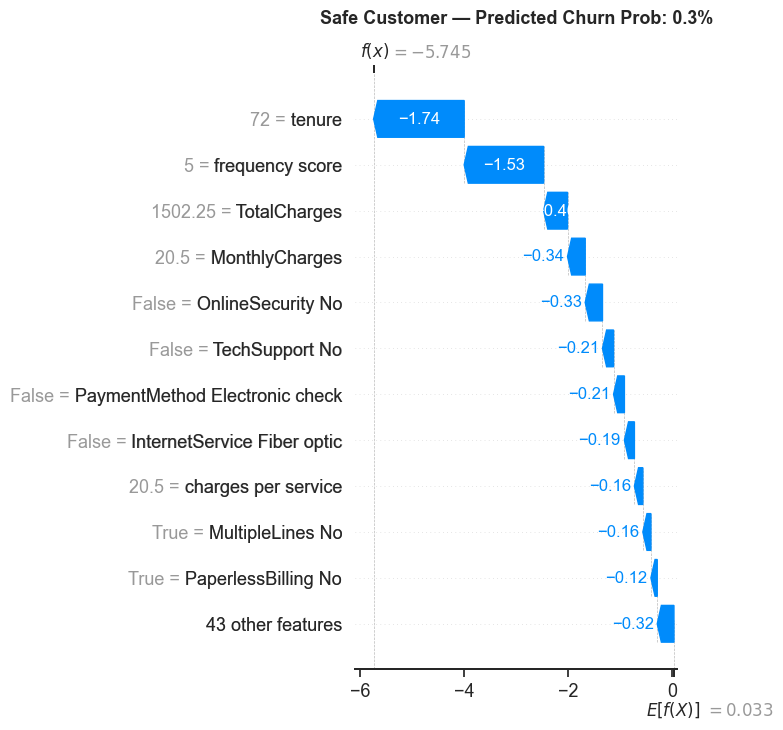

Saved → outputs/shap_waterfall_low.png


In [7]:
def save_waterfall(shap_vals, pos, title, filename):
    """Generate and save a SHAP waterfall plot for one customer."""
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.waterfall(shap_vals[pos], max_display=12, show=False)
    plt.title(title, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(f'../outputs/{filename}')
    plt.show()
    print(f"Saved → outputs/{filename}")


# HIGH RISK customer
save_waterfall(
    shap_values_display,
    pos_high,
    f'High Risk Customer — Predicted Churn Prob: {prob_series[idx_high]*100:.1f}%',
    'shap_waterfall_high.png'
)

# BORDERLINE customer
save_waterfall(
    shap_values_display,
    pos_mid,
    f'Borderline Customer — Predicted Churn Prob: {prob_series[idx_mid]*100:.1f}%',
    'shap_waterfall_mid.png'
)

# SAFE customer
save_waterfall(
    shap_values_display,
    pos_low,
    f'Safe Customer — Predicted Churn Prob: {prob_series[idx_low]*100:.1f}%',
    'shap_waterfall_low.png'
)

## 7. Top 5 Features — Plain English Interpretation

**Interview talking point:** Being able to translate SHAP values into
plain business language is what separates a data scientist from a
pure ML engineer. Always prepare this explanation.

In [8]:
# Calculate mean absolute SHAP value per feature
mean_shap = pd.DataFrame({
    'feature'   : readable_names,
    'mean_shap' : np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).head(5).reset_index(drop=True)

interpretations = [
    "Customers on month-to-month contracts are significantly more likely to churn. "
    "Upgrading to annual contracts is the single most impactful retention lever.",

    "Shorter tenure customers churn most. The first 12 months are the critical "
    "retention window — onboarding and early engagement programs matter most here.",

    "Higher monthly charges correlate with churn, but churners already pay more than stayers. "
    "This means price sensitivity is real — targeted discounts for high-charge customers can help.",

    "Customers without online security churn at ~41% vs ~15% with it. "
    "Bundling security as a free trial is a low-cost, high-impact retention tactic.",

    "Fibre optic customers churn at ~42%. Despite paying more, they may have "
    "higher expectations around speed and reliability — service quality is key."
]

print("=" * 65)
print("  TOP 5 CHURN DRIVERS — PLAIN ENGLISH INTERPRETATION")
print("=" * 65)

for i, (_, row) in enumerate(mean_shap.iterrows()):
    interp = interpretations[i] if i < len(interpretations) else "See SHAP plot for details."
    print(f"\n#{i+1}  {row['feature'].upper()}")
    print(f"    Mean |SHAP|: {row['mean_shap']:.4f}")
    print(f"    Insight   : {interp}")

print("\n" + "=" * 65)

  TOP 5 CHURN DRIVERS — PLAIN ENGLISH INTERPRETATION

#1  FREQUENCY SCORE
    Mean |SHAP|: 0.8029
    Insight   : Customers on month-to-month contracts are significantly more likely to churn. Upgrading to annual contracts is the single most impactful retention lever.

#2  TENURE
    Mean |SHAP|: 0.4606
    Insight   : Shorter tenure customers churn most. The first 12 months are the critical retention window — onboarding and early engagement programs matter most here.

#3  ONLINESECURITY NO
    Mean |SHAP|: 0.2431
    Insight   : Higher monthly charges correlate with churn, but churners already pay more than stayers. This means price sensitivity is real — targeted discounts for high-charge customers can help.

#4  MONTHLYCHARGES
    Mean |SHAP|: 0.2311
    Insight   : Customers without online security churn at ~41% vs ~15% with it. Bundling security as a free trial is a low-cost, high-impact retention tactic.

#5  INTERNETSERVICE FIBER OPTIC
    Mean |SHAP|: 0.2292
    Insight   : Fibre

---
## Revenue Impact Calculator

Translate model predictions into dollar figures.
Every prediction now becomes a business decision with a price tag attached.

**Interview talking point:** `revenue_at_risk = predicted_churn_prob × MonthlyCharges`
is a simple but powerful formula. It ranks customers not just by churn probability
but by the financial cost of losing them. A customer with 60% churn prob and
$100/month charges is more valuable to retain than one with 80% prob and $30/month.

In [9]:
# Run predictions on the FULL dataset (not just test set)
y_prob_full = model.predict_proba(X)[:, 1]

df_results = df.copy()
df_results['predicted_churn_prob'] = y_prob_full

# Revenue at risk = probability × monthly charges
df_results['revenue_at_risk'] = (
    df_results['predicted_churn_prob'] * df_results['MonthlyCharges']
)

# Segment customers by risk tier
def assign_segment(prob):
    if prob > 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Safe'

df_results['segment'] = df_results['predicted_churn_prob'].apply(assign_segment)

print("Predictions added to full dataset.")
print(f"\nSegment distribution:")
print(df_results['segment'].value_counts())

Predictions added to full dataset.

Segment distribution:
segment
Safe           3727
High Risk      1660
Medium Risk    1656
Name: count, dtype: int64


## 8. Revenue Impact Summary Table

In [10]:
summary = (df_results
    .groupby('segment')
    .agg(
        customer_count        = ('predicted_churn_prob', 'count'),
        avg_churn_probability = ('predicted_churn_prob', 'mean'),
        total_revenue_at_risk = ('revenue_at_risk', 'sum')
    )
    .round(4)
    .reindex(['High Risk', 'Medium Risk', 'Safe'])
)

print("=" * 65)
print("  REVENUE IMPACT BY RISK SEGMENT")
print("=" * 65)
print(summary.to_string())
print("=" * 65)

# Total portfolio revenue at risk (High Risk only)
high_risk_revenue = df_results[df_results['segment'] == 'High Risk']['revenue_at_risk'].sum()
high_risk_count   = (df_results['segment'] == 'High Risk').sum()
high_risk_avg_charge = df_results[df_results['segment'] == 'High Risk']['MonthlyCharges'].mean()

print(f"\n💰 Total monthly revenue at risk (High Risk segment): ${high_risk_revenue:,.2f}")
print(f"   High Risk customers : {high_risk_count:,}")
print(f"   Avg monthly charge  : ${high_risk_avg_charge:.2f}")

  REVENUE IMPACT BY RISK SEGMENT
             customer_count  avg_churn_probability  total_revenue_at_risk
segment                                                                  
High Risk              1660                 0.8282            107434.9262
Medium Risk            1656                 0.5583             66164.3018
Safe                   3727                 0.1380             32189.8280

💰 Total monthly revenue at risk (High Risk segment): $107,434.93
   High Risk customers : 1,660
   Avg monthly charge  : $77.76


## 9. Retention Scenario Calculator

In [11]:
print("=" * 65)
print("  RETENTION SCENARIO ANALYSIS")
print("=" * 65)

for retain_pct in [0.10, 0.20, 0.30, 0.50]:
    customers_retained = int(high_risk_count * retain_pct)
    revenue_saved      = high_risk_revenue * retain_pct
    annual_saved       = revenue_saved * 12
    print(f"\n  Retain {retain_pct*100:.0f}% of High Risk customers:")
    print(f"    Customers retained          : {customers_retained:,}")
    print(f"    Monthly revenue saved       : ${revenue_saved:,.2f}")
    print(f"    Annual revenue saved        : ${annual_saved:,.2f}")

print("\n" + "=" * 65)
print("  Interview talking point: Even retaining just 20% of high-risk")
print("  customers generates significant monthly savings. This ROI")
print("  calculation directly justifies the cost of building this model.")
print("=" * 65)

  RETENTION SCENARIO ANALYSIS

  Retain 10% of High Risk customers:
    Customers retained          : 166
    Monthly revenue saved       : $10,743.49
    Annual revenue saved        : $128,921.91

  Retain 20% of High Risk customers:
    Customers retained          : 332
    Monthly revenue saved       : $21,486.99
    Annual revenue saved        : $257,843.82

  Retain 30% of High Risk customers:
    Customers retained          : 498
    Monthly revenue saved       : $32,230.48
    Annual revenue saved        : $386,765.73

  Retain 50% of High Risk customers:
    Customers retained          : 830
    Monthly revenue saved       : $53,717.46
    Annual revenue saved        : $644,609.56

  Interview talking point: Even retaining just 20% of high-risk
  customers generates significant monthly savings. This ROI
  calculation directly justifies the cost of building this model.


## 10. Update SQLite Database
Add `predicted_churn_prob` and `segment` to the customers table
so the Streamlit dashboard can query them directly.

In [12]:
db_path = '../outputs/churn_analysis.db'

conn = sqlite3.connect(db_path)

# Read existing customers table
existing = pd.read_sql('SELECT * FROM customers', conn)
print(f"Existing customers table: {existing.shape}")

# Merge predictions in — match on customerID
if 'customerID' in df_results.columns and 'customerID' in existing.columns:
    updates = df_results[['customerID', 'predicted_churn_prob', 'revenue_at_risk', 'segment']]
    existing = existing.drop(
        columns=[c for c in ['predicted_churn_prob', 'revenue_at_risk', 'segment']
                 if c in existing.columns]
    )
    existing = existing.merge(updates, on='customerID', how='left')
else:
    # No customerID — merge by position
    existing['predicted_churn_prob'] = df_results['predicted_churn_prob'].values
    existing['revenue_at_risk']      = df_results['revenue_at_risk'].values
    existing['segment']              = df_results['segment'].values

# Overwrite the customers table
existing.to_sql('customers', conn, if_exists='replace', index=False)

# Verify
verify = pd.read_sql("""
    SELECT segment,
           COUNT(*) as count,
           ROUND(AVG(predicted_churn_prob), 4) as avg_prob,
           ROUND(SUM(revenue_at_risk), 2) as total_rev_at_risk
    FROM customers
    GROUP BY segment
    ORDER BY avg_prob DESC
""", conn)

print("\n✅ Database updated. Verification query:")
print(verify.to_string(index=False))
conn.close()
print(f"\n✅ Saved → {db_path}")

Existing customers table: (7043, 60)

✅ Database updated. Verification query:
    segment  count  avg_prob  total_rev_at_risk
  High Risk   1660    0.8282          107434.93
Medium Risk   1656    0.5583           66164.30
       Safe   3727    0.1380           32189.83

✅ Saved → ../outputs/churn_analysis.db


## 11. Stage 4 Complete — Summary

In [13]:
outputs = [
    'outputs/shap_summary.png',
    'outputs/shap_bar.png',
    'outputs/shap_waterfall_high.png',
    'outputs/shap_waterfall_mid.png',
    'outputs/shap_waterfall_low.png',
]

print("""
╔══════════════════════════════════════════════════════════════╗
║         STAGE 4 COMPLETE — OUTPUTS CREATED                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  SHAP PLOTS                                                  ║
║  ├── shap_summary.png       (beeswarm — global view)         ║
║  ├── shap_bar.png           (bar — top 15 features)          ║
║  ├── shap_waterfall_high.png (high risk customer)            ║
║  ├── shap_waterfall_mid.png  (borderline customer)           ║
║  └── shap_waterfall_low.png  (safe customer)                 ║
║                                                              ║
║  DATABASE UPDATED                                            ║
║  └── customers table now has:                                ║
║      predicted_churn_prob, revenue_at_risk, segment          ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  Next: Stage 5 — Streamlit Dashboard (app.py)                ║
╚══════════════════════════════════════════════════════════════╝
""")

print("File check:")
for f in outputs:
    status = "✅" if os.path.exists(f'../{f}') else "❌ MISSING"
    print(f"  {status}  {f}")


╔══════════════════════════════════════════════════════════════╗
║         STAGE 4 COMPLETE — OUTPUTS CREATED                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  SHAP PLOTS                                                  ║
║  ├── shap_summary.png       (beeswarm — global view)         ║
║  ├── shap_bar.png           (bar — top 15 features)          ║
║  ├── shap_waterfall_high.png (high risk customer)            ║
║  ├── shap_waterfall_mid.png  (borderline customer)           ║
║  └── shap_waterfall_low.png  (safe customer)                 ║
║                                                              ║
║  DATABASE UPDATED                                            ║
║  └── customers table now has:                                ║
║      predicted_churn_prob, revenue_at_risk, segment          ║
║                                                              ║
╠════════════════════════

In [16]:
import os
from pathlib import Path

# Find the notebook's current location
print("Notebook is running from:", Path.cwd())
print()

# List everything 2 levels up to find data folder
for p in sorted(Path('..').rglob('*.csv')):
    print(p)

Notebook is running from: /Users/tushargupta3/100days ml/churn_project/notebooks

../data/.ipynb_checkpoints/WA_Fn-UseC_-Telco-Customer-Churn-checkpoint.csv
../data/WA_Fn-UseC_-Telco-Customer-Churn.csv
../data/telco_clean.csv
../data/telco_features.csv


In [17]:
## Calibration Curve + Brier Score
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from pathlib import Path

# Reload model
with open(Path('../outputs/churn_model.pkl'), 'rb') as f:
    model = pickle.load(f)

# Load correct data
df = pd.read_csv('../data/telco_features.csv')

# Find target column
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)

Columns: ['customerID', 'Churn', 'Churn_Binary', 'tenure', 'MonthlyCharges', 'TotalCharges', 'recency_score', 'frequency_score', 'monetary_score', 'rfm_score', 'n_services', 'charges_per_service', 'is_new_customer', 'is_senior_no_support', 'gender_Female', 'gender_Male', 'SeniorCitizen_No', 'SeniorCitizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No inte

Brier Score: 0.1618
(Lower = better. Perfect = 0. Random = 0.20 for this dataset)


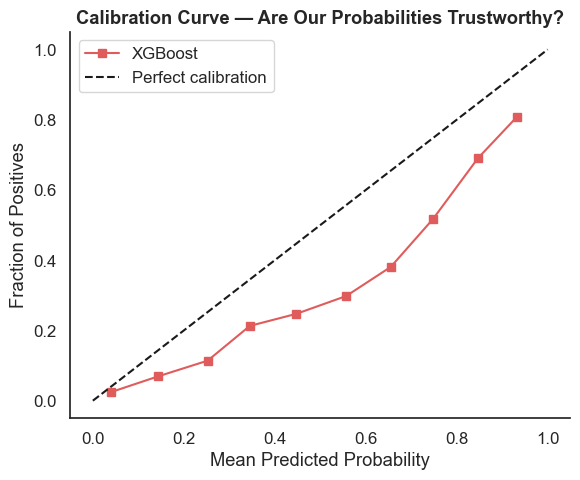

Saved → outputs/calibration_curve.png


In [18]:
## Calibration Curve + Brier Score
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from pathlib import Path

# Reload model
with open(Path('../outputs/churn_model.pkl'), 'rb') as f:
    model = pickle.load(f)

# Load data
df = pd.read_csv('../data/telco_features.csv')

# Prepare X and y — exactly as done in notebook 03
drop_cols = ['customerID', 'Churn', 'Churn_Binary']
X = df.drop(columns=drop_cols)
y = df['Churn_Binary']

# Same split as notebook 03
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_prob_final = model.predict_proba(X_test)[:, 1]

COLOR_YES = '#E05C5C'

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_prob_final, n_bins=10
)

brier = brier_score_loss(y_test, y_prob_final)
print(f"Brier Score: {brier:.4f}")
print("(Lower = better. Perfect = 0. Random = 0.20 for this dataset)")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mean_predicted_value, fraction_of_positives,
        's-', color=COLOR_YES, label='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve — Are Our Probabilities Trustworthy?',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/calibration_curve.png')
plt.show()
print('Saved → outputs/calibration_curve.png')